1.У чому різниця між .pdf(x) і .cdf(x)?

.pdf(x) (функція густини ймовірності) відповідає на запитання: «Яка щільність ймовірності в конкретній точці x?» (не є самою ймовірністю події).

.cdf(x) (кумулятивна функція розподілу) відповідає на запитання: «Яка сумарна ймовірність того, що випадкова величина набуде значення меншого або рівного x?» (це вже накопичена ймовірність від мінус нескінченності до x).

2.Чому значення .pdf(x) може бути більшим за 1 і це не помилка?

Тому що .pdf(x) — це густина ймовірності, а не сама ймовірність. Для неперервних випадкових величин ймовірність конкретного точного значення дорівнює нулю. Густина визначається швидкістю зміни кумулятивної ймовірності і може перевищувати 1 (головне, щоб інтеграл під цією кривою на всьому просторі дорівнював 1).

3.Чому .ppf() називають оберненою до .cdf() функцією?

Тому що вони виконують взаємодоповнюючі дзеркальні операції: .cdf() переводить значення у накопичену ймовірність, а .ppf() (Percent Point Function / квантильна функція) бере накопичену ймовірність і повертає відповідне їй значення вихідної шкали.

In [10]:

p95 = dist.ppf(0.95)
print(f"95-й процентиль (ppf(0.95)): {p95:.2f} °C")

95-й процентиль (ppf(0.95)): 26.43 °C


In [9]:

lower = mean_temp - std_temp
upper = mean_temp + std_temp

p_interval = dist.cdf(upper) - dist.cdf(lower)

print(f"Ймовірність потрапляння в інтервал [mean - std, mean + std]: {p_interval:.4f} ({p_interval * 100:.1f}%)")

Ймовірність потрапляння в інтервал [mean - std, mean + std]: 0.6827 (68.3%)


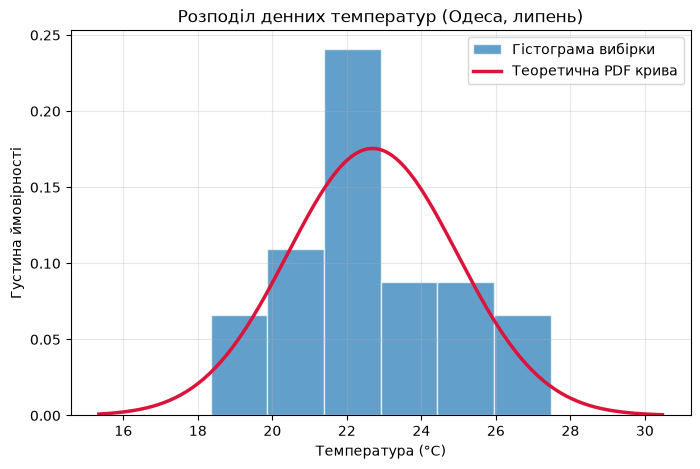

In [8]:

x = np.linspace(daily_temps.min() - 3, daily_temps.max() + 3, 200)

plt.figure(figsize=(8, 5))
plt.hist(daily_temps, bins=6, density=True, edgecolor="white", alpha=0.7, label="Гістограма вибірки")
plt.plot(x, dist.pdf(x), color="crimson", linewidth=2.5, label="Теоретична PDF крива")

plt.title("Розподіл денних температур (Одеса, липень)")
plt.xlabel("Температура (°C)")
plt.ylabel("Густина ймовірності")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:

mean_temp = daily_temps.mean()
std_temp = daily_temps.std()


dist = stats.norm(loc=mean_temp, scale=std_temp)

print(f"Параметри підібраного нормального розподілу: μ = {mean_temp:.2f}, σ = {std_temp:.2f}")

Параметри підібраного нормального розподілу: μ = 22.69, σ = 2.27


In [6]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Варіант 3: липнева температура в Одесі = 23
np.random.seed(3)
daily_temps = np.random.normal(loc=23, scale=2.5, size=30)

print("Згенеровані денні температури:")
print(daily_temps)
print("-" * 40)
print(f"Вибіркове середнє (mean): {daily_temps.mean():.2f}")
print(f"Вибіркове стандартне відхилення (std): {daily_temps.std():.2f}")

Згенеровані денні температури:
[27.47157118 24.09127463 23.24124367 18.34126824 22.30652949 22.11310255
 22.7931463  21.43249831 22.89045458 21.80695492 19.71533812 25.21155595
 25.20329511 27.27393266 23.12508411 21.98830646 21.63660013 19.13380671
 25.45591859 20.24733092 20.03738368 22.48587525 26.71537089 23.59179067
 20.44053715 21.217517   24.56311242 22.59871659 21.07790912 22.42492319]
----------------------------------------
Вибіркове середнє (mean): 22.69
Вибіркове стандартне відхилення (std): 2.27
